#### Download Required Libraries

In [1]:
!pip install requests
!pip install beautifulsoup4
!pip install lxml
!pip install pandas
!pip install matplotlib
!pip install seaborn

#### Import Libraries

In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

#### Define Website URL

In [3]:
url = "https://www.screener.in/market/"
url

'https://www.screener.in/market/'

In [4]:
headers = {
    "User-Agent":"Mozilla/5.0"
}

response = requests.get(url, headers=headers)

print(response.status_code)

200


In [5]:
soup = BeautifulSoup(response.text, "lxml")

In [6]:
links=soup.find_all("a")

In [7]:
base_url = "https://www.screener.in"

sector_urls = []

for link in links:

    href = link.get("href")

    if href and href.startswith("/market/"):

        sector_urls.append(base_url + href)

sector_urls

['https://www.screener.in/market/IN02/IN0201/IN020101/IN020101002/',
 'https://www.screener.in/market/IN07/IN0702/IN070205/IN070205016/',
 'https://www.screener.in/market/IN02/IN0204/IN020401/IN020401001/',
 'https://www.screener.in/market/IN07/IN0702/IN070201/IN070201001/',
 'https://www.screener.in/market/IN09/IN0901/IN090102/IN090102001/',
 'https://www.screener.in/market/IN09/IN0901/IN090103/IN090103001/',
 'https://www.screener.in/market/IN01/IN0103/IN010302/IN010302001/',
 'https://www.screener.in/market/IN07/IN0702/IN070205/IN070205014/',
 'https://www.screener.in/market/IN02/IN0206/IN020601/IN020601003/',
 'https://www.screener.in/market/IN04/IN0401/IN040104/IN040104001/',
 'https://www.screener.in/market/IN05/IN0501/IN050103/IN050103001/',
 'https://www.screener.in/market/IN02/IN0201/IN020102/IN020102001/',
 'https://www.screener.in/market/IN02/IN0201/IN020101/IN020101004/',
 'https://www.screener.in/market/IN06/IN0601/IN060101/IN060101002/',
 'https://www.screener.in/market/I

In [8]:
sector_urls = list(set(sector_urls))

print(len(sector_urls))

188


In [9]:
url = sector_urls[0]

response = requests.get(url, headers=headers)

soup = BeautifulSoup(response.text, "lxml")

In [10]:
table = soup.find("table")

table

<table class="data-table text-nowrap striped mark-visited no-scroll-right highlight-on-hover">
<tbody>
<tr>
<th class="text" scope="colgroup">
<a aria-label="Default Sort" class="" href="?order=asc">S.No.</a>
</th>
<th class="text" scope="colgroup">
<a aria-label="Sort on company name" class="" href="?sort=name&amp;order=desc">Company</a>
</th>
<th data-tooltip="Current Price" scope="colgroup">
<a aria-label="Sort on Current Price" class="" href="?sort=current+price&amp;order=desc">
                    CMP
                    <span style="color: hsl(0, 0%, 45%)">Rs.</span>
</a>
</th>
<th data-tooltip="Price to Earning" scope="colgroup">
<a aria-label="Sort on Price to Earning" class="" href="?sort=price+to+earning&amp;order=desc">
                    P/E
                    <span style="color: hsl(0, 0%, 45%)"></span>
</a>
</th>
<th data-tooltip="Market Capitalization" scope="colgroup">
<a aria-label="Sort on Market Capitalization" class="desc" href="?sort=market+capitalization&amp;ord

In [11]:
header_row = table.find("tr")

table_headers = [th.get_text(" ", strip=True) for th in header_row.find_all("th")]

print(table_headers)

['S.No.', 'Company', 'CMP Rs.', 'P/E', 'Mar Cap Rs.Cr.', 'Div Yld %', 'NP Qtr Rs.Cr.', 'Qtr Profit Var %', 'Sales Qtr Rs.Cr.', 'Qtr Sales Var %', 'ROCE %']


In [12]:
rows = table.find_all("tr")

In [13]:
sector_data = []

for row in rows[1:]:

    cols = row.find_all("td")

    cols = [col.text.strip() for col in cols]

    if cols:

        sector_data.append(cols)

In [14]:
df = pd.DataFrame(sector_data, columns=table_headers)
df

,S.No.,Company,CMP Rs.,P/E,Mar Cap Rs.Cr.,Div Yld %,NP Qtr Rs.Cr.,Qtr Profit Var %,Sales Qtr Rs.Cr.,Qtr Sales Var %,ROCE %
0,1.,JK Paper,408.45,22.60,7387.99,0.98,136.27,64.46,1887.17,13.61,7.39
1,2.,West Coast Paper,731.90,21.01,4826.68,0.41,141.84,145.43,1051.26,10.12,6.17
2,3.,Seshasayee Paper,246.27,15.67,1551.85,0.81,31.91,106.80,492.08,27.68,5.60
3,4.,Andhra Paper,74.05,53.20,1469.90,0.68,30.32,42.28,393.77,0.09,0.04
4,5.,N R Agarwal Inds,677.25,17.49,1154.61,0.30,34.98,111.36,646.96,43.09,8.49
5,6.,T N Newsprint,151.60,3.98,1039.39,2.64,5.74,177.46,1146.64,0.40,6.41
6,7.,Pudumjee Paper,94.47,9.82,894.56,0.64,33.72,-6.95,202.92,3.29,18.14
7,8.,Kuantum Papers,79.59,19.17,692.54,3.14,6.23,-48.34,303.75,36.26,5.24
8,9.,Emami Paper,111.87,7.23,682.67,2.86,38.61,511.89,560.16,21.84,11.44
9,10.,Satia Industries,67.00,,676.60,0.60,-17.12,-154.18,361.81,-2.46,3.94


In [15]:
sector_name = soup.find("h1").text.strip()

df["Sector"] = sector_name

In [16]:
# Take only first 15 sector URLs
sector_urls = sector_urls[:180]

print(f"Total sectors to scrape: {len(sector_urls)}")

Total sectors to scrape: 180


In [17]:
master_df = pd.DataFrame()

request_headers = {
    "User-Agent": "Mozilla/5.0"
}

for url in sector_urls:

    response = requests.get(url, headers=request_headers)

    soup = BeautifulSoup(response.text, "lxml")

    table = soup.find("table")

    if table is None:
        print(f"No table found: {url}")
        continue

    header_row = table.find("tr")

    table_headers = [
        th.get_text(" ", strip=True)
        for th in header_row.find_all("th")
    ]

    rows = table.find_all("tr")

    data = []

    for row in rows[1:]:

        cols = row.find_all("td")

        cols = [col.get_text(" ", strip=True) for col in cols]

        if len(cols) == len(table_headers):
            data.append(cols)

    df = pd.DataFrame(data, columns=table_headers)

    sector_name = soup.find("h1").get_text(strip=True)

    df["Sector"] = sector_name

    master_df = pd.concat([master_df, df], ignore_index=True)

    print(f"Completed: {sector_name}")

    time.sleep(1)

Completed: Paper & Paper Products Companies
Completed: Healthcare Research, Analytics & Technology Companies
Completed: Seafood Companies
Completed: Shipping Companies
Completed: Trading - Minerals Companies
Completed: E-Learning Companies
Completed: Real Estate Investment Trusts (REITs) Companies
Completed: Sanitary Ware Companies
Completed: Fertilizers Companies
Completed: Data Processing Services Companies
Completed: Biotechnology Companies
Completed: Diversified Retail Companies
Completed: Garments & Apparels Companies
Completed: Personal Care Companies
Completed: Asset Management Company Companies
Completed: Trading - Gas Companies
Completed: Cables - Electricals Companies
Completed: Multi Utilities Companies
Completed: Power Generation Companies
Completed: Medical Equipment & Supplies Companies
Completed: Commodity Chemicals Companies
Completed: Oil Equipment & Services Companies
Completed: Household Appliances Companies
Completed: Port & Port services Companies
Completed: Housew

#### Save the dataset

In [18]:
master_df.to_csv("Cleaned_Sector_Data.csv", index=False)

## Data Understanding

In [19]:
import pandas as pd

In [20]:
master_df=pd.read_csv('Cleaned_Sector_Data.csv')

In [21]:
master_df.head()

,S.No.,Company,CMP Rs.,P/E,Mar Cap Rs.Cr.,Div Yld %,NP Qtr Rs.Cr.,Qtr Profit Var %,Sales Qtr Rs.Cr.,Qtr Sales Var %,ROCE %,Sector
0,1.0,JK Paper,408.45,22.60,7387.99,0.98,136.27,64.46,1887.17,13.61,7.39,Paper & Paper Products Companies
1,2.0,West Coast Paper,731.90,21.01,4826.68,0.41,141.84,145.43,1051.26,10.12,6.17,Paper & Paper Products Companies
2,3.0,Seshasayee Paper,246.27,15.67,1551.85,0.81,31.91,106.80,492.08,27.68,5.60,Paper & Paper Products Companies
3,4.0,Andhra Paper,74.05,53.20,1469.90,0.68,30.32,42.28,393.77,0.09,0.04,Paper & Paper Products Companies
4,5.0,N R Agarwal Inds,677.25,17.49,1154.61,0.30,34.98,111.36,646.96,43.09,8.49,Paper & Paper Products Companies


In [22]:
master_df.shape

(2381, 12)

In [23]:
master_df.tail()

,S.No.,Company,CMP Rs.,P/E,Mar Cap Rs.Cr.,Div Yld %,NP Qtr Rs.Cr.,Qtr Profit Var %,Sales Qtr Rs.Cr.,Qtr Sales Var %,ROCE %,Sector
2376,2.0,Dec.Gold Mines,213.00,NaN,4232.54,0.0,-8.73,73.23,0.60,57.89,-15.86,Precious Metals Companies
2377,3.0,Nanavati Venture,82.50,550.42,38.53,0.0,0.03,-85.00,1.79,-65.51,0.71,Precious Metals Companies
2378,4.0,Sparkle GoldRock,65.64,6.17,29.39,0.0,0.25,516.67,12.78,590.81,48.14,Precious Metals Companies
2379,5.0,Utique Enterp.,3.83,7.13,21.32,0.0,2.32,88.62,5.31,-72.36,3.98,Precious Metals Companies
2380,6.0,Amanaya Ventures,18.00,32.03,6.73,0.0,0.04,100.00,70.03,248.75,5.54,Precious Metals Companies


In [24]:
master_df["Sector"].unique()

array(['Paper & Paper Products Companies',
       'Healthcare Research, Analytics & Technology Companies',
       'Seafood Companies', 'Shipping Companies',
       'Trading - Minerals Companies', 'E-Learning Companies',
       'Real Estate Investment Trusts (REITs) Companies',
       'Sanitary Ware Companies', 'Fertilizers Companies',
       'Data Processing Services Companies', 'Biotechnology Companies',
       'Diversified Retail Companies', 'Garments & Apparels Companies',
       'Personal Care Companies', 'Asset Management Company Companies',
       'Trading - Gas Companies', 'Cables - Electricals Companies',
       'Multi Utilities Companies', 'Power Generation Companies',
       'Medical Equipment & Supplies Companies',
       'Commodity Chemicals Companies',
       'Oil Equipment & Services Companies',
       'Household Appliances Companies', 'Port & Port services Companies',
       'Houseware Companies', 'Other Consumer Services Companies',
       'Ship Building & Allied Servic

In [25]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2381 entries, 0 to 2380
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   S.No.             2381 non-null   float64
 1   Company           2381 non-null   object 
 2   CMP Rs.           2381 non-null   float64
 3   P/E               2022 non-null   float64
 4   Mar Cap Rs.Cr.    2381 non-null   float64
 5   Div Yld %         2381 non-null   float64
 6   NP Qtr Rs.Cr.     2360 non-null   float64
 7   Qtr Profit Var %  2307 non-null   float64
 8   Sales Qtr Rs.Cr.  2360 non-null   float64
 9   Qtr Sales Var %   2244 non-null   float64
 10  ROCE %            2324 non-null   float64
 11  Sector            2381 non-null   object 
dtypes: float64(10), object(2)
memory usage: 223.3+ KB


In [30]:
master_df['Company'].nunique()

2381

In [27]:
master_df.describe()

,S.No.,CMP Rs.,P/E,Mar Cap Rs.Cr.,Div Yld %,NP Qtr Rs.Cr.,Qtr Profit Var %,Sales Qtr Rs.Cr.,Qtr Sales Var %,ROCE %
count,2381.00000,2.381000e+03,2022.000000,2.381000e+03,2381.000000,2360.000000,2307.000000,2360.000000,2244.000000,2324.000000
mean,10.02226,1.762822e+03,74.902216,1.897641e+04,0.580281,215.475894,177.361348,2435.356275,60.148485,10.501106
std,6.96829,3.013499e+04,721.663757,7.470656e+04,1.395493,1244.663842,3199.043113,14173.929961,735.033123,147.266986
min,1.00000,1.900000e-01,0.420000,1.400000e+00,0.000000,-12264.670000,-29250.000000,0.000000,-100.000000,-7026.090000
25%,4.00000,6.280000e+01,14.160000,1.897100e+02,0.000000,1.180000,-15.335000,40.537500,3.747500,5.910000
50%,9.00000,1.910700e+02,25.365000,1.244230e+03,0.000000,11.000000,23.450000,198.550000,17.230000,12.110000
75%,15.00000,5.989500e+02,47.255000,8.120500e+03,0.620000,69.600000,84.875000,899.800000,34.842500,19.670000
max,25.00000,1.060000e+06,30565.230000,1.659361e+06,31.220000,25120.890000,107300.000000,309468.000000,28133.330000,162.470000


In [31]:
master_df.isnull().sum()

,0
S.No.,0
Company,0
CMP Rs.,0
P/E,359
Mar Cap Rs.Cr.,0
Div Yld %,0
NP Qtr Rs.Cr.,21
Qtr Profit Var %,74
Sales Qtr Rs.Cr.,21
Qtr Sales Var %,137


In [32]:
master_df.duplicated().sum()

np.int64(0)

In [33]:
master_df["Sector"].value_counts()

,count
Sector,
Paper & Paper Products Companies,25
Medical Equipment & Supplies Companies,25
Power Generation Companies,25
Fertilizers Companies,25
Cables - Electricals Companies,25
...,...
Multi Utilities Companies,1
Glass - Consumer Companies,1
Insurance Distributors Companies,1


In [35]:
print(master_df["Company"].nunique())

2381


In [36]:
print(master_df["Sector"].nunique())

180


In [37]:
master_df.dtypes

,0
S.No.,float64
Company,object
CMP Rs.,float64
P/E,float64
Mar Cap Rs.Cr.,float64
Div Yld %,float64
NP Qtr Rs.Cr.,float64
Qtr Profit Var %,float64
Sales Qtr Rs.Cr.,float64
Qtr Sales Var %,float64


## Data Cleaning

In [38]:
master_df["Mar Cap Rs.Cr."]

,Mar Cap Rs.Cr.
0,7387.99
1,4826.68
2,1551.85
3,1469.90
4,1154.61
...,...
2376,4232.54
2377,38.53
2378,29.39
2379,21.32


In [39]:
numeric_cols = [
    "CMP Rs.",
    "P/E",
    "Mar Cap Rs.Cr.",
    "Div Yld %",
    "NP Qtr Rs.Cr.",
    "Qtr Profit Var %",
    "Sales Qtr Rs.Cr.",
    "Qtr Sales Var %",
    "ROCE %"
]

for col in numeric_cols:
    master_df[col] = pd.to_numeric(master_df[col], errors="coerce")

In [40]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2381 entries, 0 to 2380
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   S.No.             2381 non-null   float64
 1   Company           2381 non-null   object 
 2   CMP Rs.           2381 non-null   float64
 3   P/E               2022 non-null   float64
 4   Mar Cap Rs.Cr.    2381 non-null   float64
 5   Div Yld %         2381 non-null   float64
 6   NP Qtr Rs.Cr.     2360 non-null   float64
 7   Qtr Profit Var %  2307 non-null   float64
 8   Sales Qtr Rs.Cr.  2360 non-null   float64
 9   Qtr Sales Var %   2244 non-null   float64
 10  ROCE %            2324 non-null   float64
 11  Sector            2381 non-null   object 
dtypes: float64(10), object(2)
memory usage: 223.3+ KB


In [41]:
master_df.isnull().sum()

,0
S.No.,0
Company,0
CMP Rs.,0
P/E,359
Mar Cap Rs.Cr.,0
Div Yld %,0
NP Qtr Rs.Cr.,21
Qtr Profit Var %,74
Sales Qtr Rs.Cr.,21
Qtr Sales Var %,137


#### Filling null values with the median of the particular sector

In [42]:
numeric_cols = [
    "P/E",
    "NP Qtr Rs.Cr.",
    "Qtr Profit Var %",
    "Sales Qtr Rs.Cr.",
    "Qtr Sales Var %",
    "ROCE %"
]

for col in numeric_cols:
    master_df[col] = master_df.groupby("Sector")[col].transform(
        lambda x: x.fillna(x.median())
    )

In [43]:
master_df.isnull().sum()

,0
S.No.,0
Company,0
CMP Rs.,0
P/E,0
Mar Cap Rs.Cr.,0
Div Yld %,0
NP Qtr Rs.Cr.,0
Qtr Profit Var %,0
Sales Qtr Rs.Cr.,0
Qtr Sales Var %,0


# Descriptive Stats

In [44]:
numeric_cols = [
    "CMP Rs.",
    "P/E",
    "Mar Cap Rs.Cr.",
    "Div Yld %",
    "NP Qtr Rs.Cr.",
    "Qtr Profit Var %",
    "Sales Qtr Rs.Cr.",
    "Qtr Sales Var %",
    "ROCE %"
]

master_df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
CMP Rs.,2381.0,1762.822310,30134.986795,0.19,62.80,191.07,598.95,1060000.00
P/E,2381.0,67.621644,665.261294,0.42,14.71,24.91,43.17,30565.23
Mar Cap Rs.Cr.,2381.0,18976.405842,74706.556879,1.40,189.71,1244.23,8120.50,1659361.00
Div Yld %,2381.0,0.580281,1.395493,0.00,0.00,0.00,0.62,31.22
NP Qtr Rs.Cr.,2381.0,213.835664,1239.310720,-12264.67,1.17,10.58,69.38,25120.89
Qtr Profit Var %,2381.0,172.713851,3149.028396,-29250.00,-13.98,23.47,81.94,107300.00
Sales Qtr Rs.Cr.,2381.0,2415.748604,14112.847534,0.00,40.34,192.87,890.96,309468.00
Qtr Sales Var %,2381.0,57.683589,713.642768,-100.00,4.01,17.03,34.11,28133.33
ROCE %,2381.0,10.511084,145.495435,-7026.09,5.92,12.06,19.54,162.47


In [45]:
stats_summary = master_df[numeric_cols].agg(
    ["mean", "median", "std", "min", "max"]
).T

stats_summary

,mean,median,std,min,max
CMP Rs.,1762.822310,191.07,30134.986795,0.19,1060000.00
P/E,67.621644,24.91,665.261294,0.42,30565.23
Mar Cap Rs.Cr.,18976.405842,1244.23,74706.556879,1.40,1659361.00
Div Yld %,0.580281,0.00,1.395493,0.00,31.22
NP Qtr Rs.Cr.,213.835664,10.58,1239.310720,-12264.67,25120.89
Qtr Profit Var %,172.713851,23.47,3149.028396,-29250.00,107300.00
Sales Qtr Rs.Cr.,2415.748604,192.87,14112.847534,0.00,309468.00
Qtr Sales Var %,57.683589,17.03,713.642768,-100.00,28133.33
ROCE %,10.511084,12.06,145.495435,-7026.09,162.47


In [46]:
#Sector-wise Descriptive Statistics

sector_stats = master_df.groupby("Sector")[[
    "P/E",
    "Mar Cap Rs.Cr.",
    "Div Yld %",
    "Qtr Profit Var %",
    "Qtr Sales Var %",
    "ROCE %"
]].agg(["mean", "median", "std"])

sector_stats.head()

P/E                       \
                                              mean   median         std   
Sector                                                                    
2/3 Wheelers Companies                   38.291538   22.870   42.849876   
Abrasives & Bearings Companies          110.152222   68.500  128.533923   
Advertising & Media Agencies Companies   68.776400   11.360  278.844605   
Airline Companies                        22.725000   22.725    3.178445   
Airport & Airport services Companies    183.410000  183.410    0.000000   

                                       Mar Cap Rs.Cr.            \
                                                 mean    median   
Sector                                                            
2/3 Wheelers Companies                   69001.016154   2235.34   
Abrasives & Bearings Companies           10524.042222   7616.90   
Advertising & Media Agencies Companies     181.794800     50.87   
Airline Companies                        39101.036000   1503.21   
Airport & Airport services Companies     51696.380000  51696.38   

                                                      Div Yld %         \
                                                  std      mean median   
Sector                                                                   
2/3 Wheelers Companies                  103817.527236  0.643846   0.00   
Abrasives & Bearings Companies           10751.167744  0.632222   0.35   
Advertising & Media Agencies Companies     318.209163  0.450800   0.00   
Airline Companies                        84923.512318  0.280000   0.00   
Airport & Airport services Companies     72631.576116  0.000000   0.00   

                                                 Qtr Profit Var %         \
                                             std             mean median   
Sector                                                                     
2/3 Wheelers Companies                  1.040461         2.761538  21.35   
Abrasives & Bearings Companies          0.812046         3.852222  15.44   
Advertising & Media Agencies Companies  1.116292       633.606400  20.91   
Airline Companies                       0.521536      -227.944000 -25.66   
Airport & Airport services Companies    0.000000       -10.090000 -10.09   

                                                    Qtr Sales Var %         \
                                                std            mean median   
Sector                                                                       
2/3 Wheelers Companies                    67.798896       23.526923  31.55   
Abrasives & Bearings Companies            43.876254       13.820000  14.87   
Advertising & Media Agencies Companies  2640.793284      102.698000  15.82   
Airline Companies                        494.296596       27.850000  19.94   
Airport & Airport services Companies     218.001021      -32.530000 -32.53   

                                                       ROCE %         \
                                               std       mean median   
Sector                                                                 
2/3 Wheelers Companies                   48.951329  13.310769  13.28   
Abrasives & Bearings Companies           13.410242  11.050000  11.38   
Advertising & Media Agencies Companies  421.775309  20.641600  17.96   
Airline Companies                        25.144981  14.040000   9.10   
Airport & Airport services Companies     79.606081   8.710000   8.71   

                                                   
                                              std  
Sector                                             
2/3 Wheelers Companies                  18.119824  
Abrasives & Bearings Companies          13.290656  
Advertising & Media Agencies Companies  22.470730  
Airline Companies                       15.417839  
Airport & Airport services Companies     4.157788

In [47]:
# Correlation Analysis

corr = master_df[numeric_cols].corr()

corr

,CMP Rs.,P/E,Mar Cap Rs.Cr.,Div Yld %,NP Qtr Rs.Cr.,Qtr Profit Var %,Sales Qtr Rs.Cr.,Qtr Sales Var %,ROCE %
CMP Rs.,1.000000,0.016298,0.006414,0.076424,0.000516,0.278939,-0.001166,-0.002395,0.001033
P/E,0.016298,1.000000,-0.006996,-0.022590,-0.011442,0.016457,-0.009086,0.013092,-0.002590
Mar Cap Rs.Cr.,0.006414,-0.006996,1.000000,0.112638,0.833531,-0.008783,0.631801,-0.010776,0.015418
Div Yld %,0.076424,-0.022590,0.112638,1.000000,0.148529,0.028816,0.171202,-0.018441,0.018048
NP Qtr Rs.Cr.,0.000516,-0.011442,0.833531,0.148529,1.000000,-0.004045,0.566658,-0.008913,0.010286
Qtr Profit Var %,0.278939,0.016457,-0.008783,0.028816,-0.004045,1.000000,-0.005917,0.016403,0.003711
Sales Qtr Rs.Cr.,-0.001166,-0.009086,0.631801,0.171202,0.566658,-0.005917,1.000000,-0.007499,0.007079
Qtr Sales Var %,-0.002395,0.013092,-0.010776,-0.018441,-0.008913,0.016403,-0.007499,1.000000,0.015462
ROCE %,0.001033,-0.002590,0.015418,0.018048,0.010286,0.003711,0.007079,0.015462,1.000000


# Inferential Statistics

Test 1 — Pearson Correlation Significance

In [48]:
#Is the relationship between Sales Growth and Profit Growth statistically significant?
from scipy.stats import pearsonr

test_df = master_df[
    ["Qtr Sales Var %", "Qtr Profit Var %"]
].dropna()

r, p_value = pearsonr(
    test_df["Qtr Sales Var %"],
    test_df["Qtr Profit Var %"]
)

print("Correlation:", r)
print("P-value:", p_value)

Correlation: 0.016402980483228965
P-value: 0.4236963028863379


## Exploratory Data Analysis

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipykernel_1361/1050724235.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


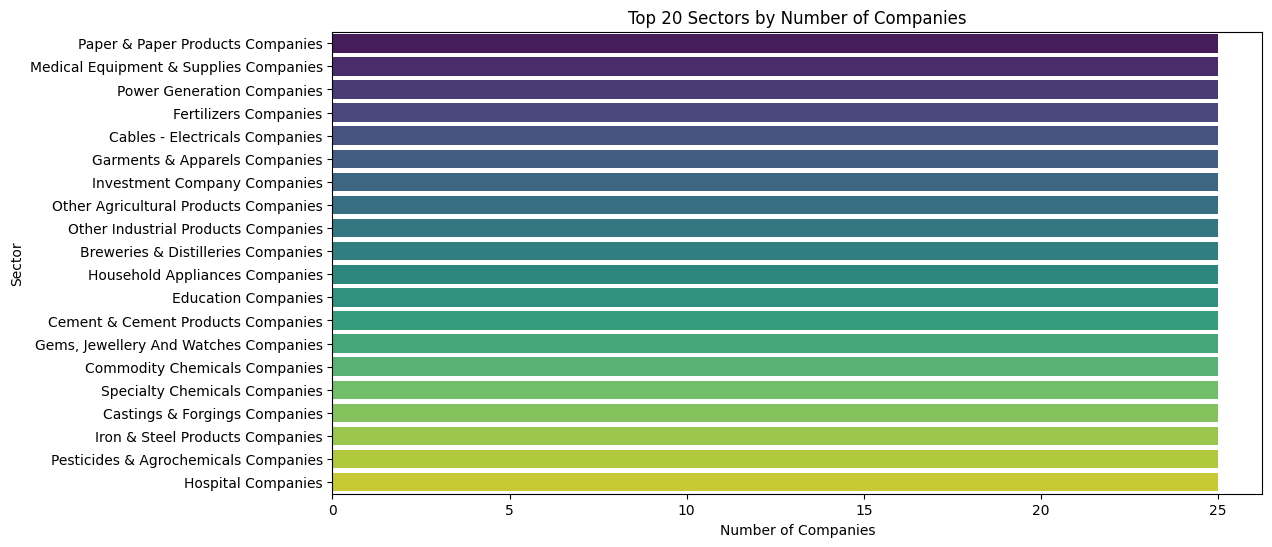

In [50]:
#1. Companies per Sector

sector_count = master_df["Sector"].value_counts().nlargest(20)

plt.figure(figsize=(12,6))
sns.barplot(
    x=sector_count.values,
    y=sector_count.index,
    palette="viridis"
)

plt.title("Top 20 Sectors by Number of Companies")
plt.xlabel("Number of Companies")
plt.ylabel("Sector")
plt.show()

/tmp/ipykernel_1361/646997158.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


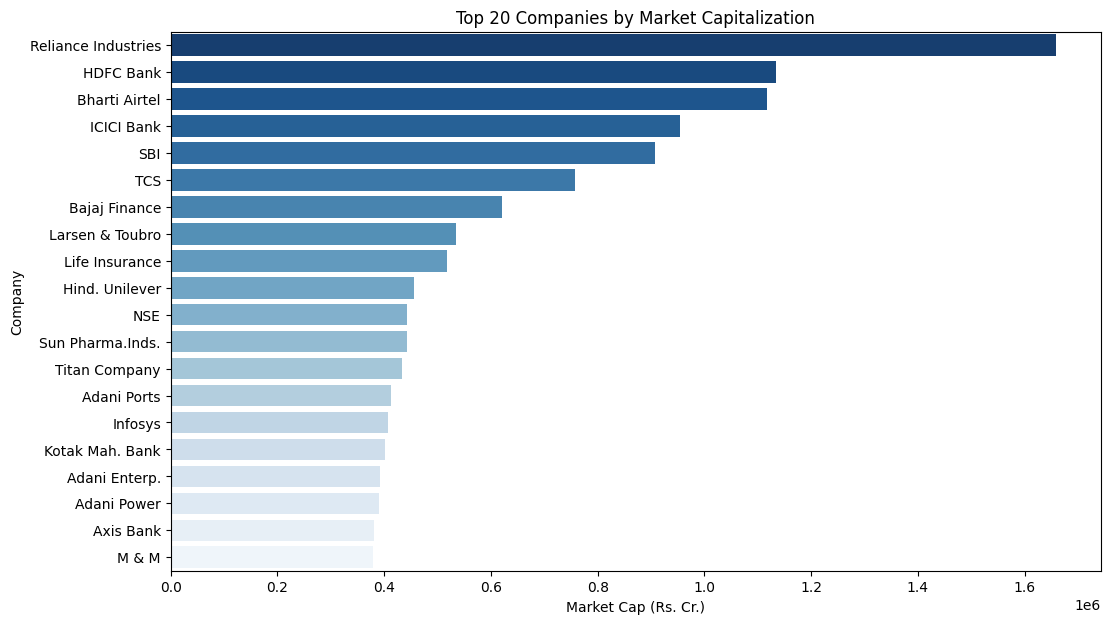

In [53]:
#2. Top 20 Companies by Market Capitalization

#Which companies dominate the market?

top_market = master_df.nlargest(20, "Mar Cap Rs.Cr.")

plt.figure(figsize=(12,7))
sns.barplot(
    data=top_market,
    x="Mar Cap Rs.Cr.",
    y="Company",
    palette="Blues_r"
)

plt.title("Top 20 Companies by Market Capitalization")
plt.xlabel("Market Cap (Rs. Cr.)")
plt.ylabel("Company")
plt.show()

/tmp/ipykernel_1361/58103627.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


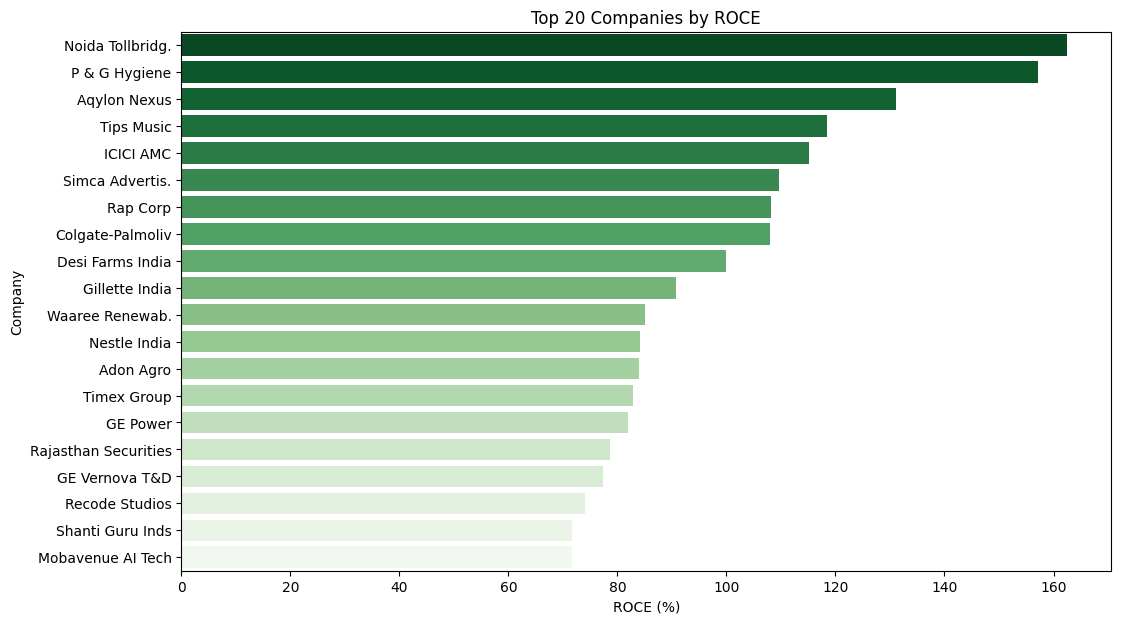

In [55]:
#3. Top 20 Companies by ROCE

#Which companies utilize capital most efficiently?

top_roce = master_df.nlargest(20, "ROCE %")

plt.figure(figsize=(12,7))
sns.barplot(
    data=top_roce,
    x="ROCE %",
    y="Company",
    palette="Greens_r"
)

plt.title("Top 20 Companies by ROCE")
plt.xlabel("ROCE (%)")
plt.ylabel("Company")
plt.show()

/tmp/ipykernel_1361/3529029233.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


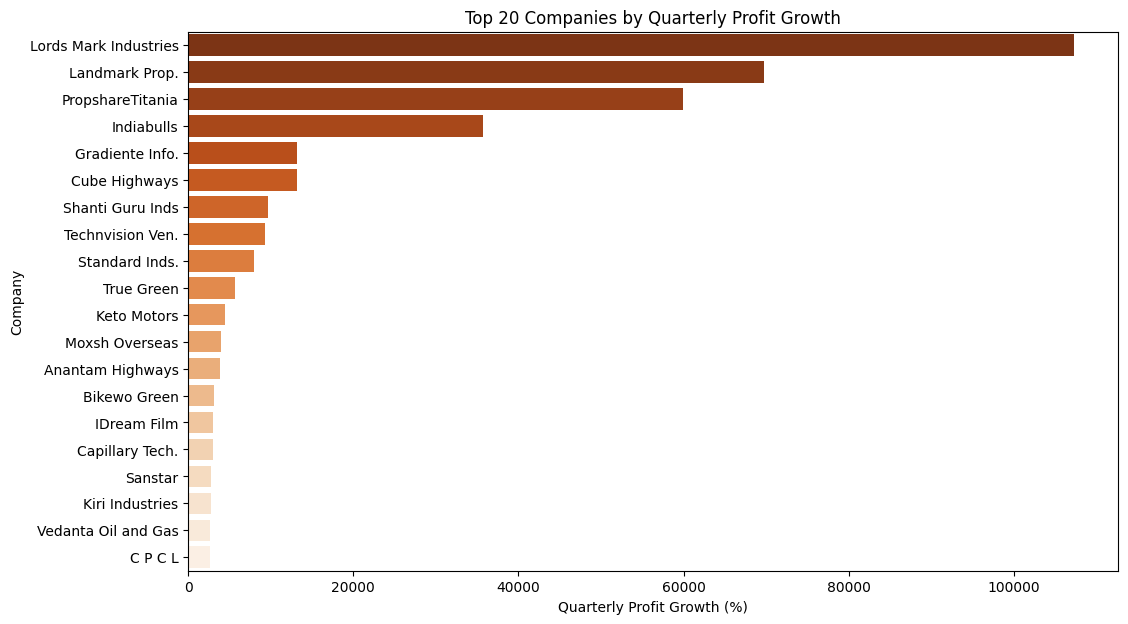

In [57]:
#4. Top 20 Companies by Quarterly Profit Growth

top_profit = master_df.nlargest(20, "Qtr Profit Var %")

plt.figure(figsize=(12,7))
sns.barplot(
    data=top_profit,
    x="Qtr Profit Var %",
    y="Company",
    palette="Oranges_r"
)

plt.title("Top 20 Companies by Quarterly Profit Growth")
plt.xlabel("Quarterly Profit Growth (%)")
plt.ylabel("Company")
plt.show()

/tmp/ipykernel_1361/3625221634.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


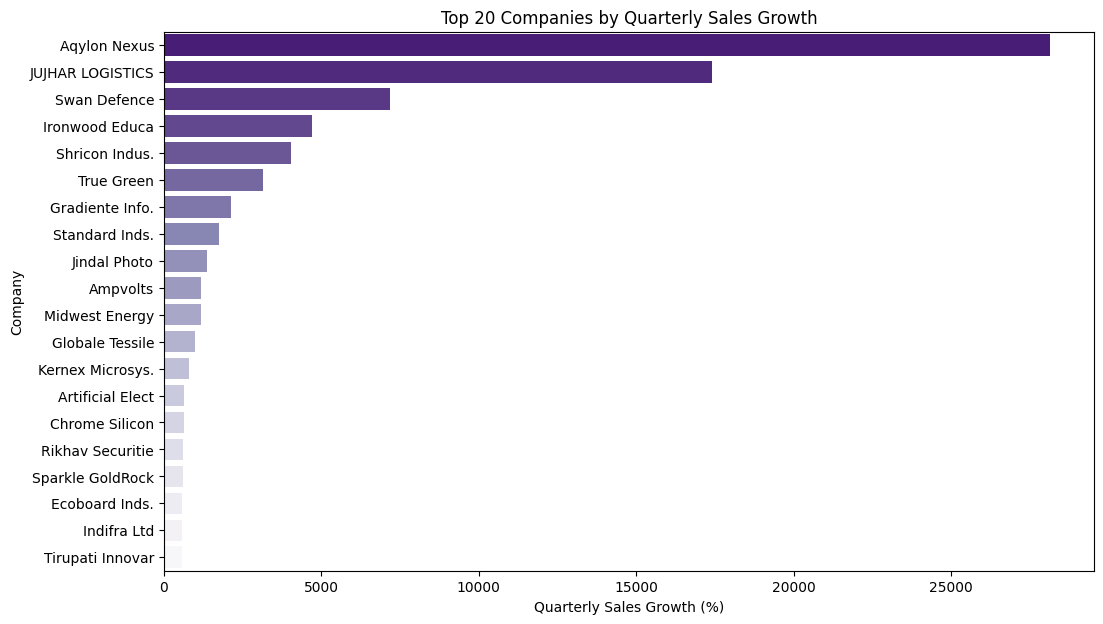

In [59]:
#5. Top 20 Companies by Quarterly Sales Growth

top_sales = master_df.nlargest(20, "Qtr Sales Var %")

plt.figure(figsize=(12,7))
sns.barplot(
    data=top_sales,
    x="Qtr Sales Var %",
    y="Company",
    palette="Purples_r"
)

plt.title("Top 20 Companies by Quarterly Sales Growth")
plt.xlabel("Quarterly Sales Growth (%)")
plt.ylabel("Company")
plt.show()

In [60]:
import warnings
warnings.filterwarnings('ignore')

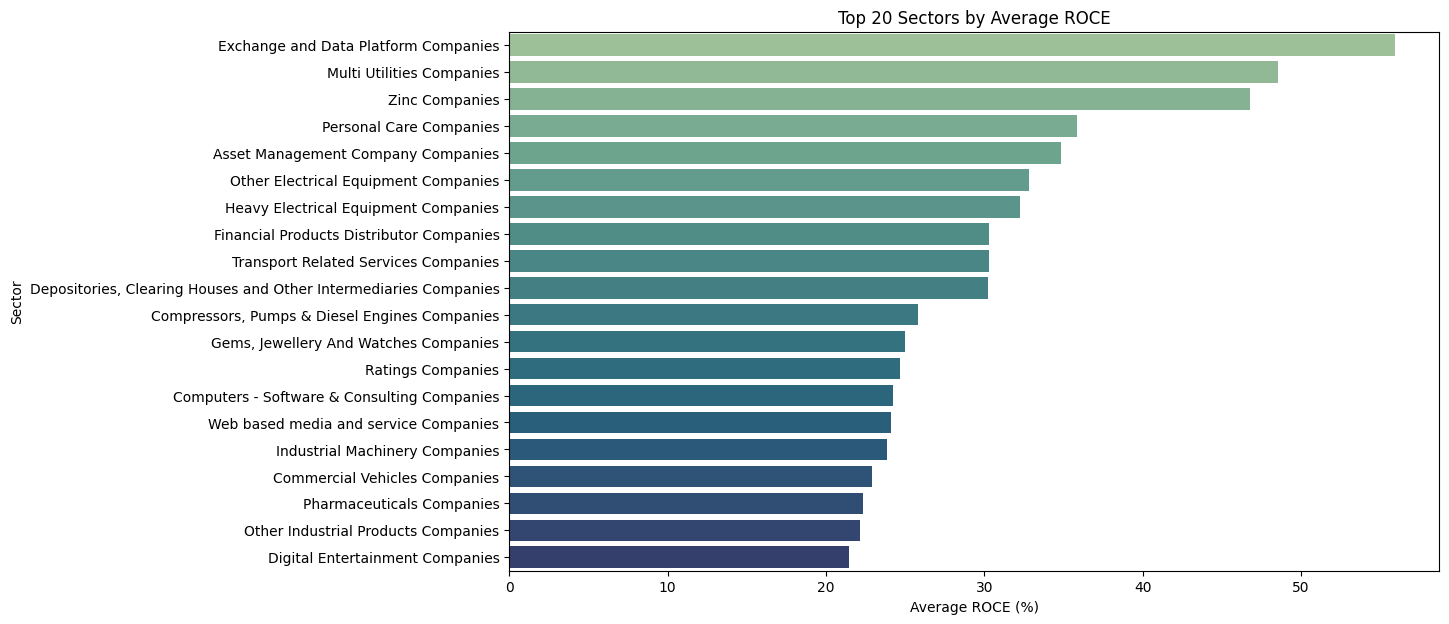

In [61]:
#6. Average ROCE by Sector

sector_roce = (
    master_df.groupby("Sector")["ROCE %"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(12,7))
sns.barplot(
    x=sector_roce.values,
    y=sector_roce.index,
    palette="crest"
)

plt.title("Top 20 Sectors by Average ROCE")
plt.xlabel("Average ROCE (%)")
plt.ylabel("Sector")
plt.show()

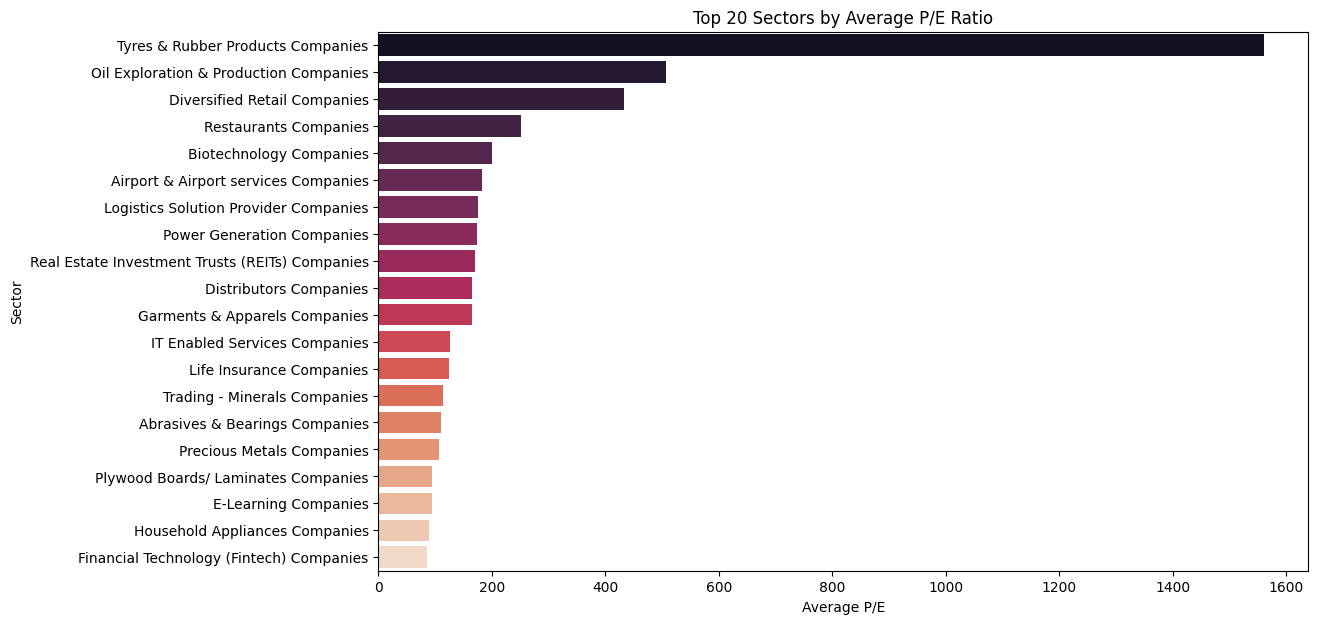

In [62]:
#7. Average P/E by Sector

sector_pe = (
    master_df.groupby("Sector")["P/E"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(12,7))
sns.barplot(
    x=sector_pe.values,
    y=sector_pe.index,
    palette="rocket"
)

plt.title("Top 20 Sectors by Average P/E Ratio")
plt.xlabel("Average P/E")
plt.ylabel("Sector")
plt.show()

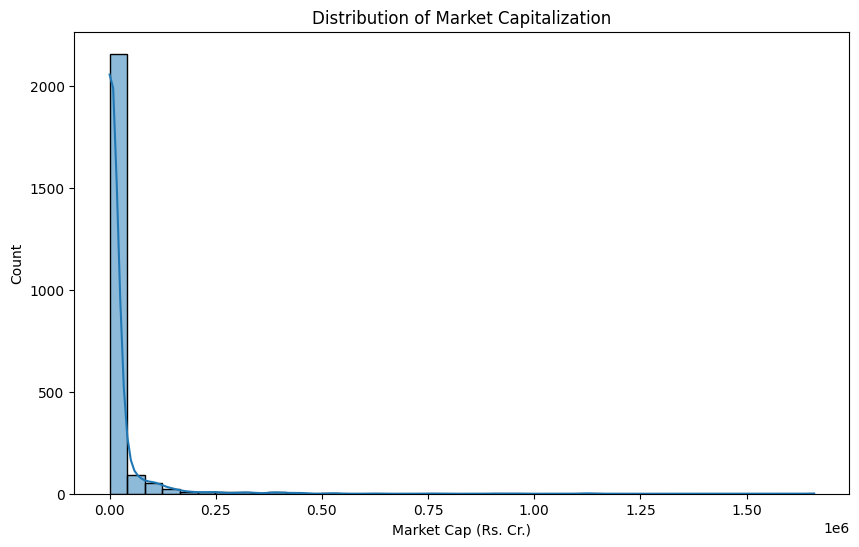

In [63]:
#8. Market Cap Distribution

plt.figure(figsize=(10,6))

sns.histplot(
    master_df["Mar Cap Rs.Cr."],
    bins=40,
    kde=True
)

plt.title("Distribution of Market Capitalization")
plt.xlabel("Market Cap (Rs. Cr.)")
plt.show()

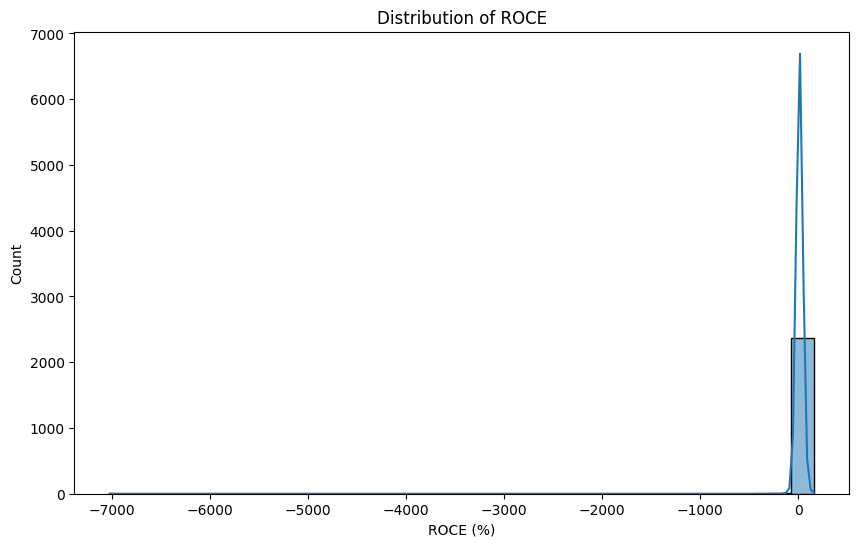

In [64]:
#9. ROCE Distribution

plt.figure(figsize=(10,6))

sns.histplot(
    master_df["ROCE %"],
    bins=30,
    kde=True
)

plt.title("Distribution of ROCE")
plt.xlabel("ROCE (%)")
plt.show()

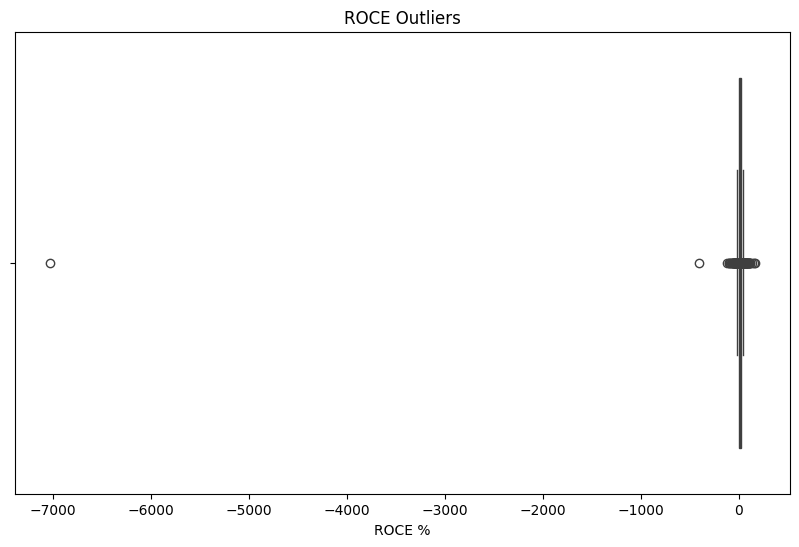

In [65]:
#10. Boxplot (Outlier Detection)

plt.figure(figsize=(10,6))

sns.boxplot(
    x=master_df["ROCE %"]
)

plt.title("ROCE Outliers")
plt.show()

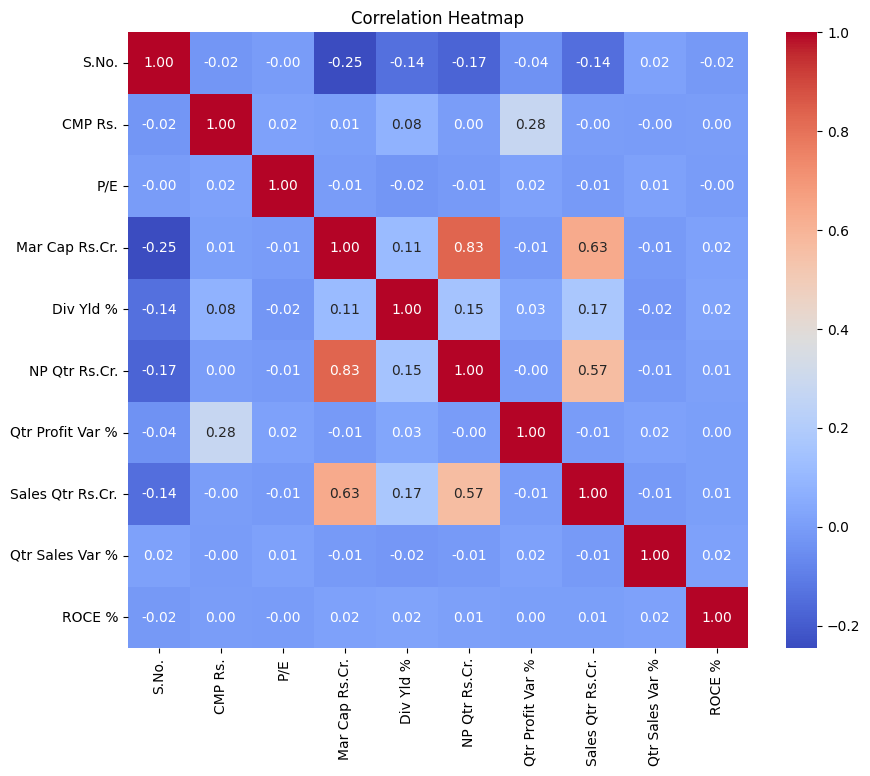

In [66]:
#11. Correlation Heatmap

plt.figure(figsize=(10,8))

numeric_df = master_df.select_dtypes(include="number")

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

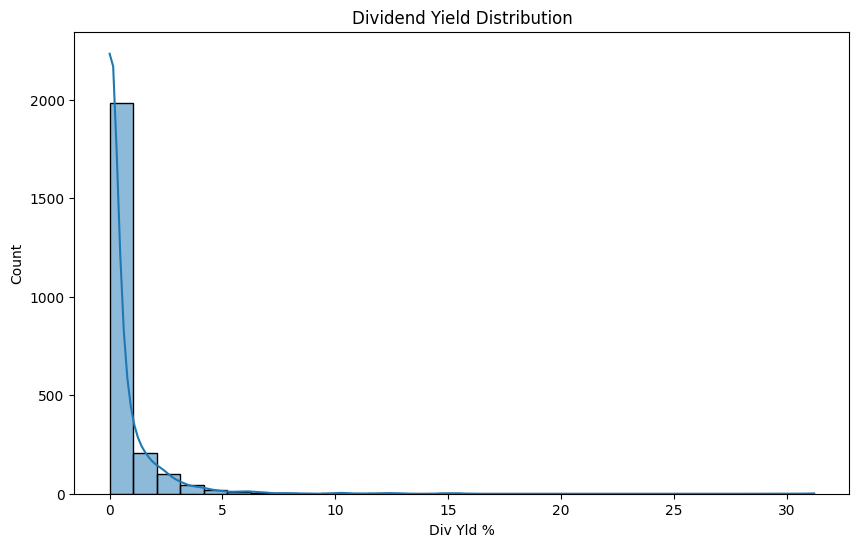

In [67]:
# 14. Dividend Yield Distribution

plt.figure(figsize=(10,6))

sns.histplot(
    master_df["Div Yld %"],
    bins=30,
    kde=True
)

plt.title("Dividend Yield Distribution")
plt.show()

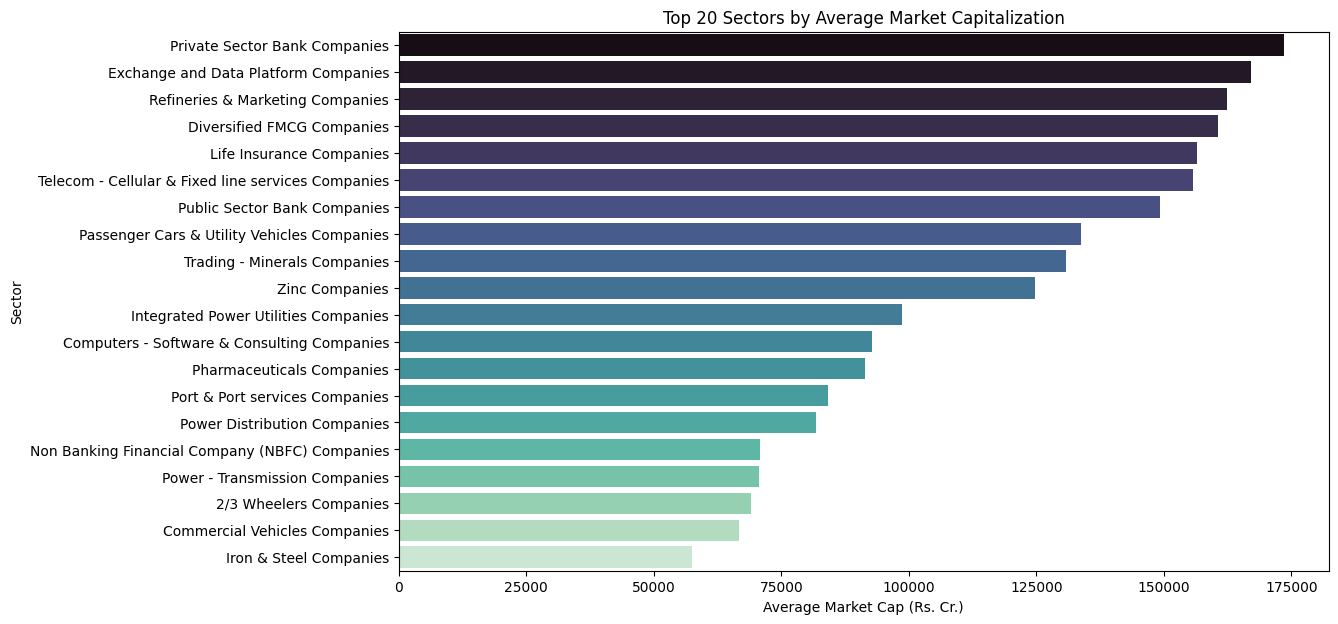

In [68]:
#15. Top 20 Sectors by Average Market Cap

sector_cap = (
    master_df.groupby("Sector")["Mar Cap Rs.Cr."]
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(12,7))

sns.barplot(
    x=sector_cap.values,
    y=sector_cap.index,
    palette="mako"
)

plt.title("Top 20 Sectors by Average Market Capitalization")
plt.xlabel("Average Market Cap (Rs. Cr.)")
plt.ylabel("Sector")
plt.show()

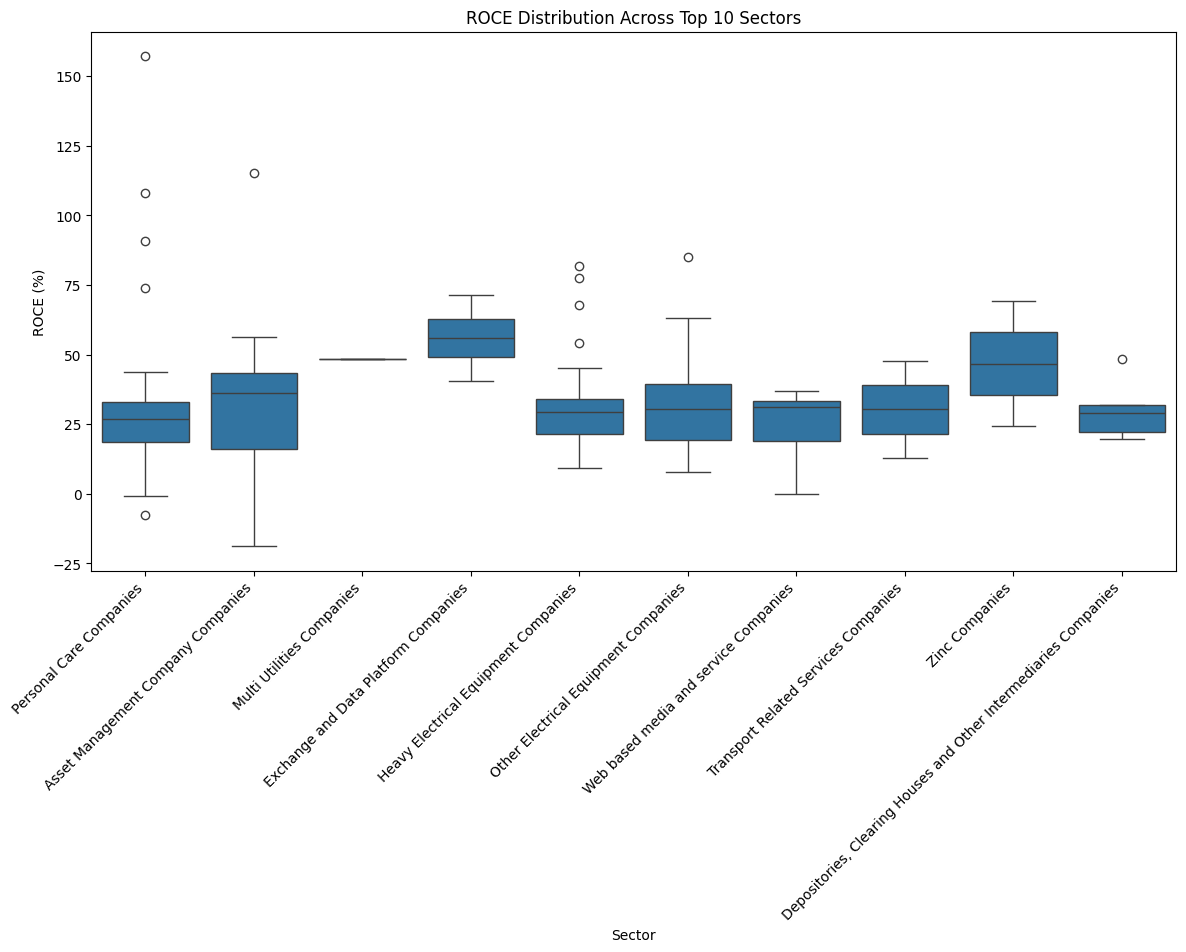

In [69]:
top_sectors = (
    master_df.groupby("Sector")["ROCE %"]
    .median()
    .nlargest(10)
    .index
)

plot_df = master_df[
    master_df["Sector"].isin(top_sectors)
]

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=plot_df,
    x="Sector",
    y="ROCE %"
)

plt.xticks(rotation=45, ha="right")

plt.title("ROCE Distribution Across Top 10 Sectors")
plt.xlabel("Sector")
plt.ylabel("ROCE (%)")

plt.show()

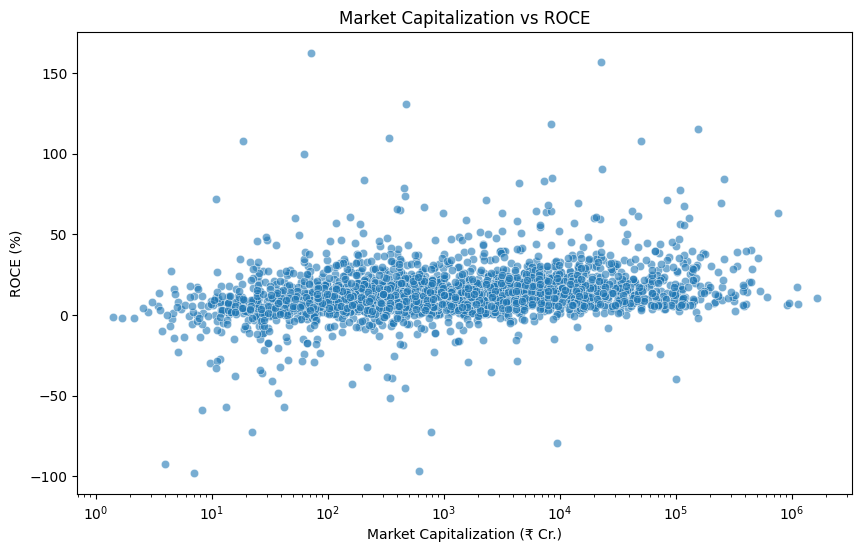

In [70]:
#Do larger companies use their capital more efficiently?
scatter_df = master_df[
    (master_df["ROCE %"] >= -100) &
    (master_df["ROCE %"] <= 200)
].copy()

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=scatter_df,
    x="Mar Cap Rs.Cr.",
    y="ROCE %",
    alpha=0.6
)

plt.xscale("log")

plt.title("Market Capitalization vs ROCE")
plt.xlabel("Market Capitalization (₹ Cr.)")
plt.ylabel("ROCE (%)")

plt.show()

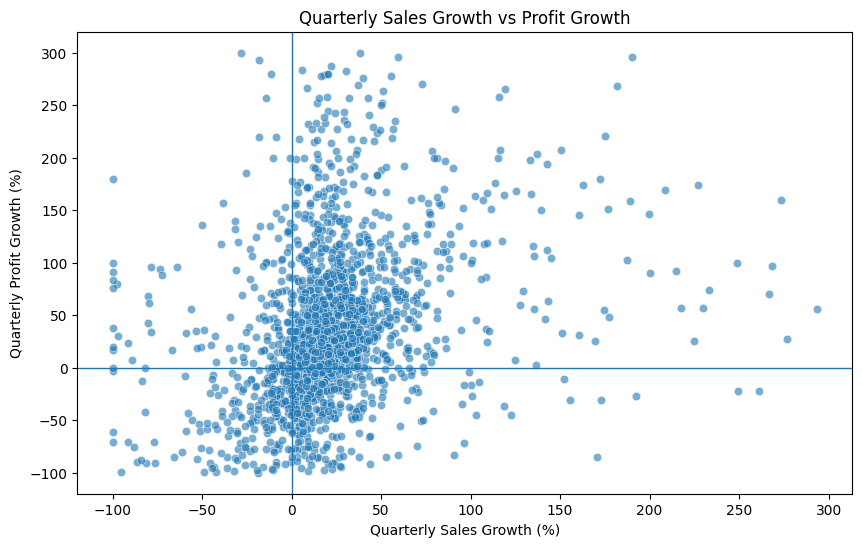

In [71]:
#Does increasing sales translate into increasing profit?
growth_df = master_df[
    (master_df["Qtr Sales Var %"].between(-100, 300)) &
    (master_df["Qtr Profit Var %"].between(-100, 300))
].copy()

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=growth_df,
    x="Qtr Sales Var %",
    y="Qtr Profit Var %",
    alpha=0.6
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.title("Quarterly Sales Growth vs Profit Growth")
plt.xlabel("Quarterly Sales Growth (%)")
plt.ylabel("Quarterly Profit Growth (%)")

plt.show()